# Post-GUI Analysis: Predict All Traces & Label Deep-Dive

**Workflow:**
1. Load pre-computed data (`trace_data.pkl`) and labels (`labels.json`) from the GUI
2. Train the classifier on all labeled traces
3. Predict every trace → build a results DataFrame
4. In-depth per-label analysis (feature distributions, example traces, UMAP)
5. Export results to CSV

In [1]:
# ── paths (edit if needed) ────────────────────────────────────────────────
PICKLE_PATH = "../results/trace_data.pkl"  # pre-computed data from --prepare
LABELS_PATH = "../labels/test.json"  # saved by the GUI
RESULTS_CSV = "../results/predictions.csv"  # output: full predictions + features
EXPORT_PKL = "../results/traces_labeled.pkl"  # output: raw traces + step fits + labels
# ─────────────────────────────────────────────────────────────────────────

import sys, warnings
from pathlib import Path

# Ensure the project root is on sys.path so gui_labeler can be imported
_PROJECT_ROOT = (
    str(Path(__file__).resolve().parent.parent)
    if "__file__" in dir()
    else str(Path.cwd().parent)
)
if _PROJECT_ROOT not in sys.path:
    sys.path.insert(0, _PROJECT_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)
plt.rcParams.update(
    {"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False}
)
print("Imports OK")

Imports OK


## 1. Load Data & Labels

In [ ]:
from gui_labeler.serialization import load_prepared_data
from gui_labeler.labeler import ActiveLabeler, UNLABELED
from gui_labeler import config

all_data, pelt_results, channel_names = load_prepared_data(PICKLE_PATH)

labeler = ActiveLabeler(
    all_data=all_data,
    new_results=pelt_results,
    channels=config.CHANNELS,
    channel_colors=config.CHANNEL_COLORS,
    calibration=config.CALIBRATION,
)

n_loaded = labeler.load(LABELS_PATH)
print(f"Loaded {n_loaded} labels from {LABELS_PATH}")
print("Label counts:", labeler.label_counts())

Loading pre-computed data from ../results/trace_data.pkl …
  7 experiments, 9158 tracks total
Extracting features from all tracks …
  9158 tracks, 49 features each
Loaded 217 labels from ../labels/test.json
Label counts: {'normal': np.int64(118), 'hcs70': np.int64(66), 'non_interesting': np.int64(33)}


## 2. Train Classifier on All Labels

In [4]:
model, msg = labeler.train()
print(msg)

if model is None:
    raise RuntimeError("Training failed – need ≥ 2 distinct labels.")

Round 16: 217 labeled ({'normal': np.int64(118), 'hcs70': np.int64(66), 'non_interesting': np.int64(33)})
  Train acc: 1.000  |  CV acc: 0.778


## 3. Build Predictions DataFrame

In [5]:
label_arr = labeler.get_label_array()  # human labels or UNLABELED
pred_arr = labeler.model.predict(labeler.feat_df.values)
proba_arr = labeler.proba  # shape (N, n_classes)
classes = labeler.classes
max_prob = proba_arr.max(axis=1)

df = labeler.index_df.copy()
df["human_label"] = label_arr
df["predicted_label"] = pred_arr
df["confidence"] = max_prob
df["is_labeled"] = label_arr != UNLABELED

# add per-class probabilities
for i, cls in enumerate(classes):
    df[f"prob_{cls}"] = proba_arr[:, i]

# merge in feature matrix
df = pd.concat(
    [df.reset_index(drop=True), labeler.feat_df.reset_index(drop=True)], axis=1
)

print(df.shape)
print("\nPrediction distribution (all tracks):")
print(df["predicted_label"].value_counts())
print("\nPrediction distribution (unlabeled only):")
print(df.loc[~df.is_labeled, "predicted_label"].value_counts())
df.head(3)

(9158, 58)

Prediction distribution (all tracks):
predicted_label
normal             7405
non_interesting    1176
hcs70               577
Name: count, dtype: int64

Prediction distribution (unlabeled only):
predicted_label
normal             7287
non_interesting    1143
hcs70               511
Name: count, dtype: int64


,exp,idx,human_label,predicted_label,confidence,is_labeled,prob_hcs70,prob_non_interesting,prob_normal,clathrin_n_pos_steps,...,auxilin_range,auxilin_initial,auxilin_final,auxilin_net_change,auxilin_med_pos_step,auxilin_first_pos_frame,lifetime,n_frames,hsc70_aux_step_ratio,hsc70_aux_mol_ratio
0,Ex01,0,hcs70,hcs70,0.999874,True,9.998745e-01,5.921024e-07,0.000125,1,...,142.538208,-0.953061,-49.983596,-49.030535,13.703924,6.0057,120.114,600,0.500000,1.311623
1,Ex01,1,__unlabeled__,non_interesting,0.613415,False,1.628866e-02,6.134152e-01,0.370296,0,...,NaN,NaN,NaN,NaN,0.000000,NaN,120.114,600,0.000000,0.000000
2,Ex01,2,__unlabeled__,normal,1.000000,False,2.287635e-08,2.544952e-08,1.000000,1,...,193.347183,0.790924,-14.501727,-15.292651,27.652089,6.0057,120.114,600,0.666667,0.497011


In [6]:
df.to_csv(RESULTS_CSV, index=False)
print(f"Saved → {RESULTS_CSV}")

Saved → ../results/predictions.csv


In [ ]:
import pickle

# Build a fast lookup (exp, idx) -> (predicted_label, confidence)
pred_lookup = {
    (row.exp, int(row.idx)): (row.predicted_label, row.confidence)
    for _, row in df[["exp", "idx", "predicted_label", "confidence"]].iterrows()
}

records = []
for exp in config.EXPERIMENTS:
    for idx, tr in enumerate(all_data[exp]):
        nr = pelt_results[exp][idx]
        key = (exp, idx)
        pred_lbl, conf = pred_lookup.get(key, (UNLABELED, float("nan")))
        record = {
            "exp": exp,
            "idx": idx,
            "label": labeler.labels.get(f"{exp}:{idx}", UNLABELED),
            "predicted_label": pred_lbl,
            "confidence": conf,
            "time": tr["time"],
            "lifetime_s": tr["lifetime_s"],
        }
        for ch in config.CHANNELS:
            fit = nr[ch]["fit"]
            sf = np.asarray(nr[ch]["step_frames"], dtype=int)
            sizes = (
                np.array([float(fit[f] - fit[f - 1]) for f in sf])
                if len(sf) > 0
                else np.array([])
            )
            record[f"{ch}_raw"] = tr[ch]
            record[f"{ch}_fit"] = fit
            record[f"{ch}_step_frames"] = sf
            record[f"{ch}_step_sizes"] = sizes
            record[f"{ch}_n_steps"] = int(nr[ch]["n_steps"])
        records.append(record)

with open(EXPORT_PKL, "wb") as f:
    pickle.dump(records, f, protocol=pickle.HIGHEST_PROTOCOL)

n_labeled = sum(1 for r in records if r["label"] != UNLABELED)
n_pred = sum(1 for r in records if r["predicted_label"] != UNLABELED)
size_mb = Path(EXPORT_PKL).stat().st_size / 1e6
print(
    f"Saved {len(records)} tracks ({n_labeled} labeled, {n_pred} with predictions) "
    f"→ {EXPORT_PKL}  ({size_mb:.1f} MB)"
)
print("\nrecords[0] keys:", list(records[0].keys()))

## 4. Label Overview

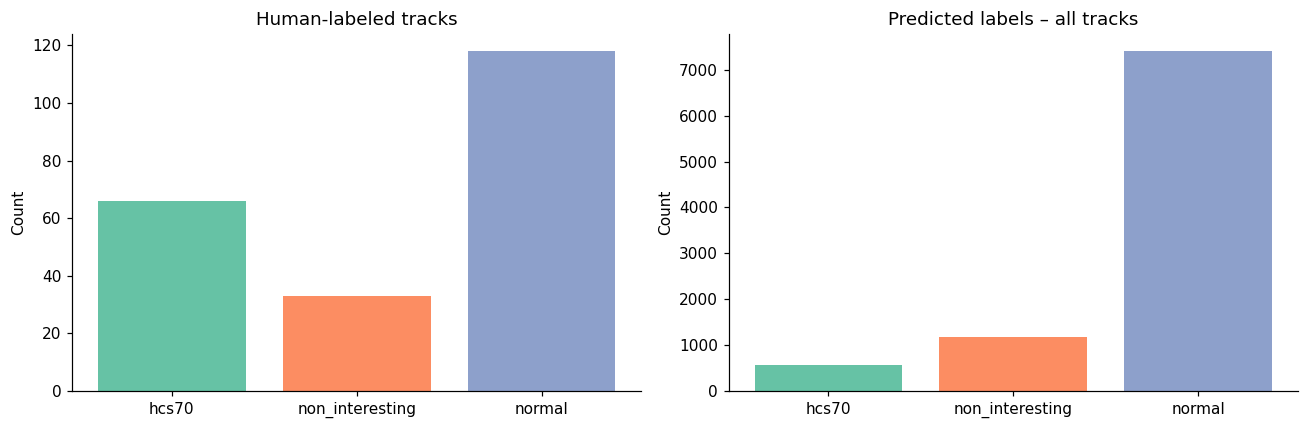

In [ ]:
label_order = sorted(classes)
colors = sns.color_palette("Set2", len(label_order))
color_map = dict(zip(label_order, colors))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# left: human label counts
human_counts = (
    pd.Series(labeler.labels.values()).value_counts().reindex(label_order, fill_value=0)
)
axes[0].bar(
    human_counts.index,
    human_counts.values,
    color=[color_map[l] for l in human_counts.index],
)
axes[0].set_title("Human-labeled tracks")
axes[0].set_ylabel("Count")

# right: predicted counts across ALL tracks
pred_counts = df["predicted_label"].value_counts().reindex(label_order, fill_value=0)
axes[1].bar(
    pred_counts.index,
    pred_counts.values,
    color=[color_map[l] for l in pred_counts.index],
)
axes[1].set_title("Predicted labels – all tracks")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## 5. Confidence Distribution per Label

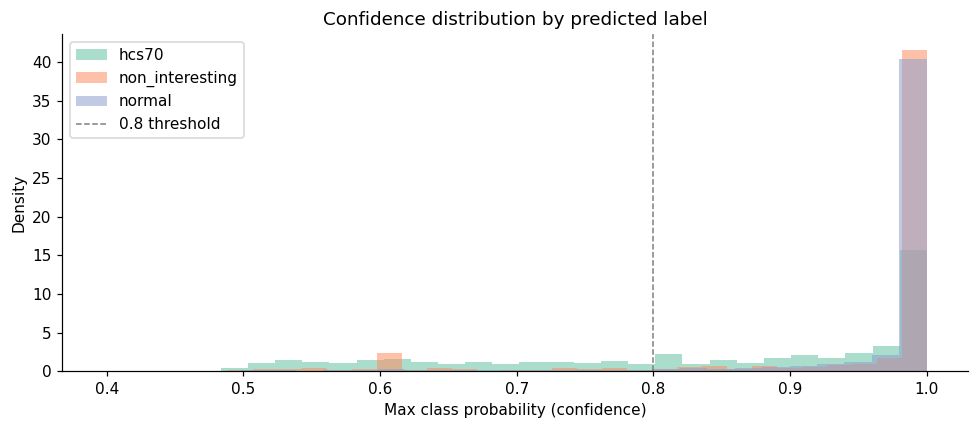

High-confidence (≥0.8) counts:
predicted_label
normal             7015
non_interesting    1041
hcs70               371
Name: count, dtype: int64


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
for label in label_order:
    subset = df.loc[df.predicted_label == label, "confidence"]
    ax.hist(
        subset, bins=30, alpha=0.55, label=label, color=color_map[label], density=True
    )
ax.set_xlabel("Max class probability (confidence)")
ax.set_ylabel("Density")
ax.set_title("Confidence distribution by predicted label")
ax.axvline(0.8, ls="--", color="gray", lw=1, label="0.8 threshold")
ax.legend()
plt.tight_layout()
plt.show()

print("High-confidence (≥0.8) counts:")
print(df.loc[df.confidence >= 0.8, "predicted_label"].value_counts())

## 6. Feature Distributions per Label

Violin plots for the most informative features, split by predicted label.

/var/folders/p4/gq4wzy6j6_5dsrhjmb74bh7c0000gn/T/ipykernel_36903/1013351152.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/p4/gq4wzy6j6_5dsrhjmb74bh7c0000gn/T/ipykernel_36903/1013351152.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/p4/gq4wzy6j6_5dsrhjmb74bh7c0000gn/T/ipykernel_36903/1013351152.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/var/folders/p4/gq4wzy6j6_5dsrhjmb74bh7c0000gn/T/ipykernel_36903/1013351152.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is dep

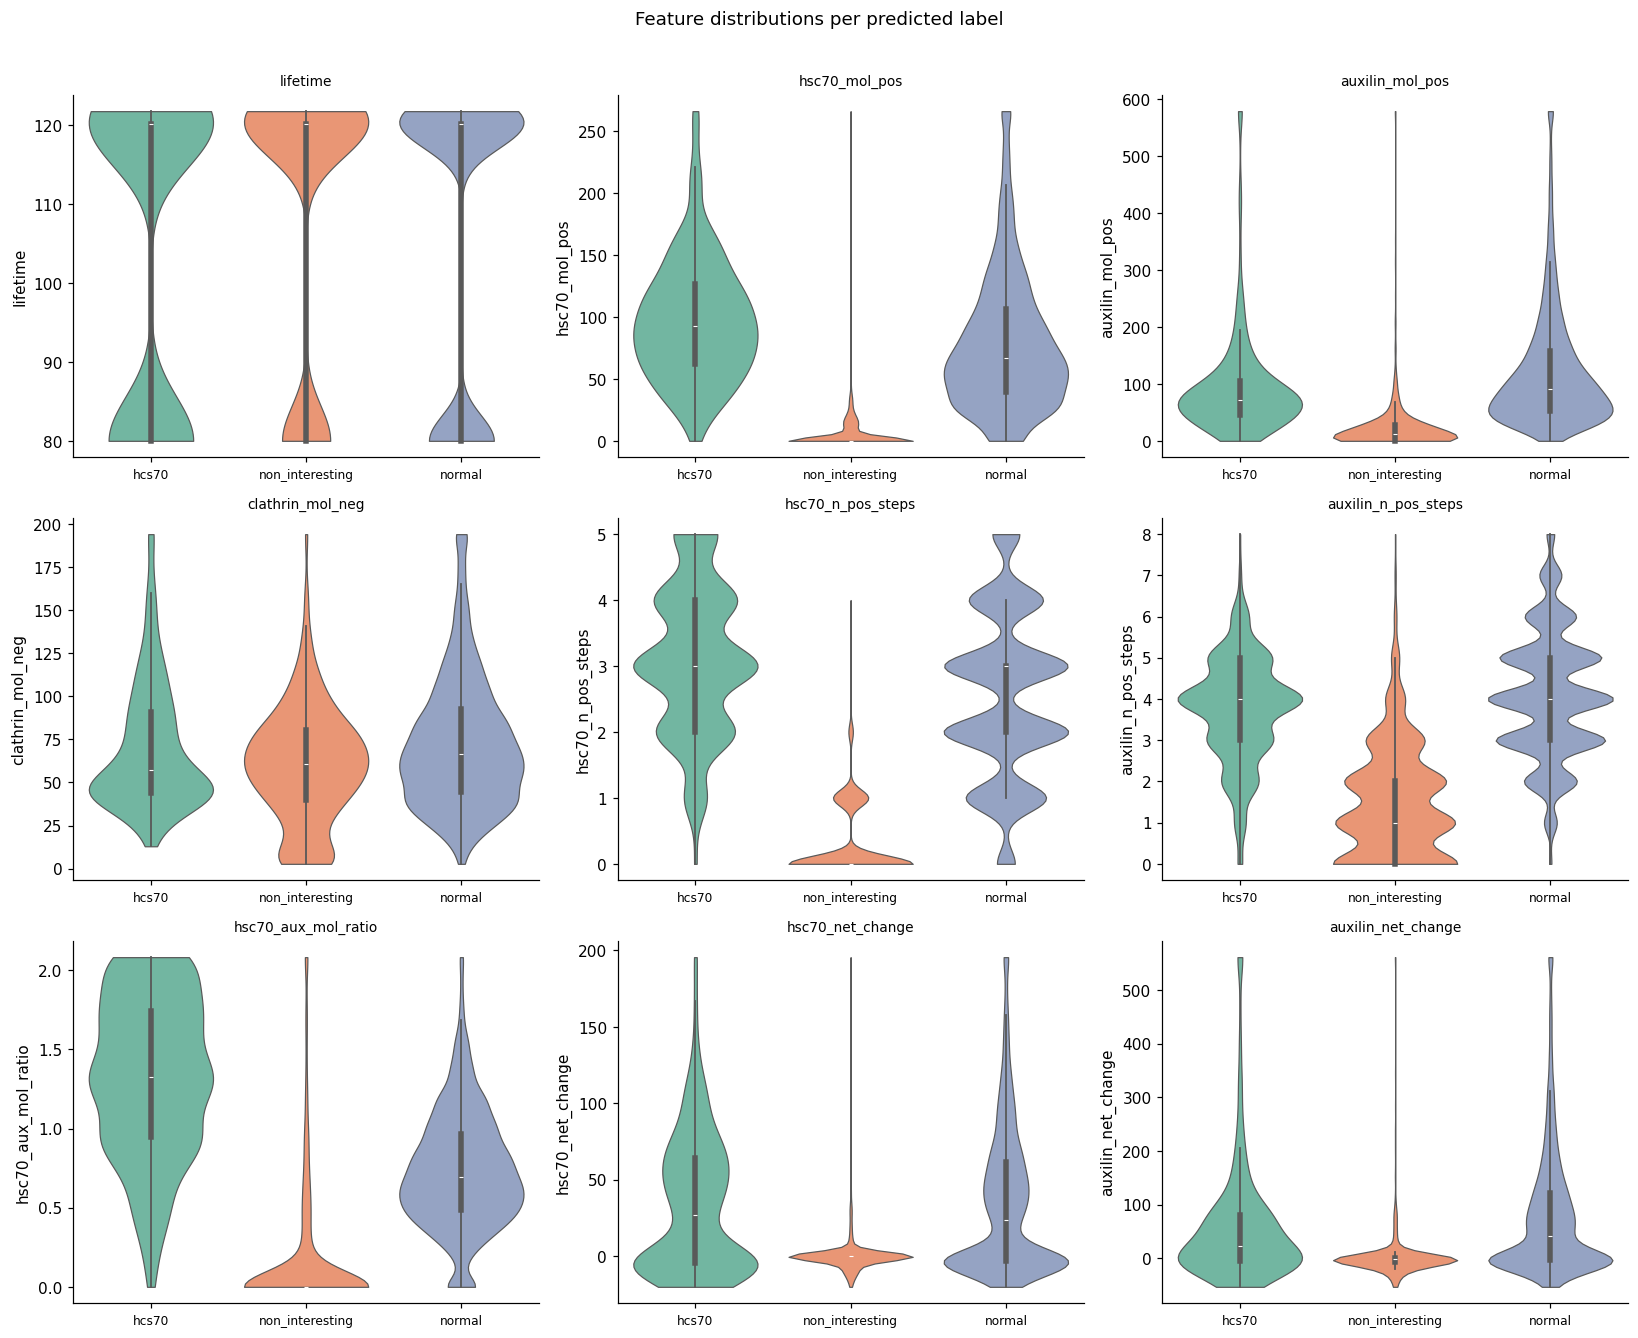

In [ ]:
KEY_FEATURES = [
    "lifetime",
    "hsc70_mol_pos",
    "auxilin_mol_pos",
    "clathrin_mol_neg",
    "hsc70_n_pos_steps",
    "auxilin_n_pos_steps",
    "hsc70_aux_mol_ratio",
    "hsc70_net_change",
    "auxilin_net_change",
]
KEY_FEATURES = [f for f in KEY_FEATURES if f in df.columns]

n = len(KEY_FEATURES)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for i, feat in enumerate(KEY_FEATURES):
    ax = axes[i]
    plot_df = df[["predicted_label", feat]].copy().dropna()
    # clip extreme outliers for legibility
    lo, hi = plot_df[feat].quantile(0.01), plot_df[feat].quantile(0.99)
    plot_df[feat] = plot_df[feat].clip(lo, hi)
    sns.violinplot(
        data=plot_df,
        x="predicted_label",
        y=feat,
        order=label_order,
        palette=color_map,
        ax=ax,
        inner="box",
        cut=0,
        linewidth=0.8,
    )
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel("")
    ax.tick_params(axis="x", labelsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature distributions per predicted label", y=1.01, fontsize=12)
plt.tight_layout()
plt.show()

## 7. Feature Importance (from the trained model)

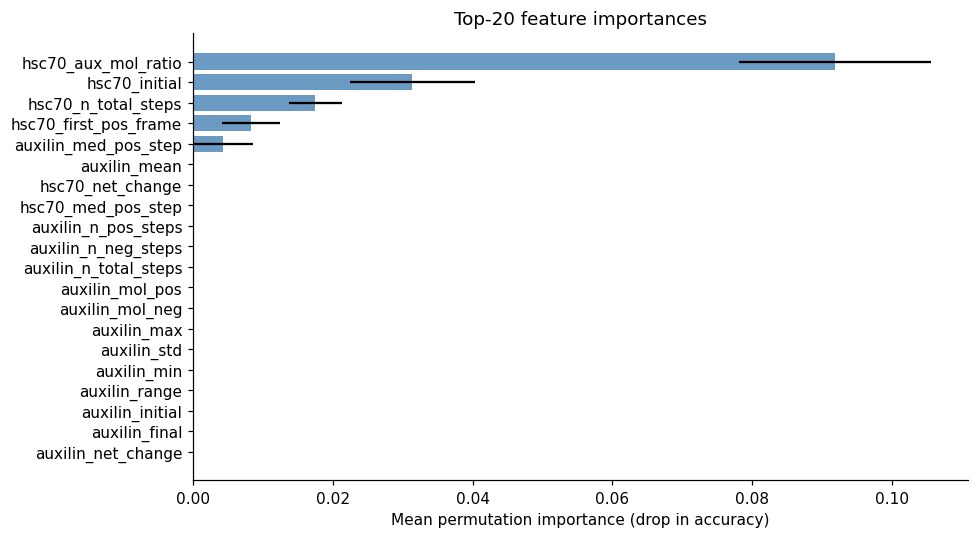

,feature,importance,std
48,hsc70_aux_mol_ratio,0.091859,0.013719
25,hsc70_initial,0.031336,0.008936
17,hsc70_n_total_steps,0.017512,0.003837
29,hsc70_first_pos_frame,0.008295,0.004190
43,auxilin_med_pos_step,0.004301,0.004279
35,auxilin_mean,0.000000,0.000000
27,hsc70_net_change,0.000000,0.000000
28,hsc70_med_pos_step,0.000000,0.000000
30,auxilin_n_pos_steps,0.000000,0.000000
31,auxilin_n_neg_steps,0.000000,0.000000


In [ ]:
# HistGradientBoostingClassifier exposes feature importances via permutation
from sklearn.inspection import permutation_importance

labeled_mask = labeler.get_labeled_mask()
label_arr_l = labeler.get_label_array()
X_lab = labeler.feat_df.values[labeled_mask]
y_lab = label_arr_l[labeled_mask]

r = permutation_importance(
    labeler.model, X_lab, y_lab, n_repeats=15, random_state=42, scoring="accuracy"
)

imp_df = pd.DataFrame(
    {
        "feature": labeler.feat_df.columns,
        "importance": r.importances_mean,
        "std": r.importances_std,
    }
).sort_values("importance", ascending=False)

top = imp_df.head(20)
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    top.feature[::-1],
    top.importance[::-1],
    xerr=top["std"][::-1],
    color="steelblue",
    alpha=0.8,
)
ax.set_xlabel("Mean permutation importance (drop in accuracy)")
ax.set_title("Top-20 feature importances")
plt.tight_layout()
plt.show()

imp_df.head(20)

## 8. UMAP Embedding (2-D)

Colour by predicted label; marker shape = human-labeled vs. predicted-only.

In [11]:
try:
    import umap
except ImportError:
    raise ImportError("pip install umap-learn")

from sklearn.impute import SimpleImputer

X_raw = labeler.feat_df.values.copy()
# Replace inf → NaN, then impute with median
X_raw = np.where(np.isinf(X_raw), np.nan, X_raw)
imp = SimpleImputer(strategy="median")
X_imp = imp.fit_transform(X_raw)

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
emb = reducer.fit_transform(X_imp)
print("UMAP done:", emb.shape)

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP done: (9158, 2)


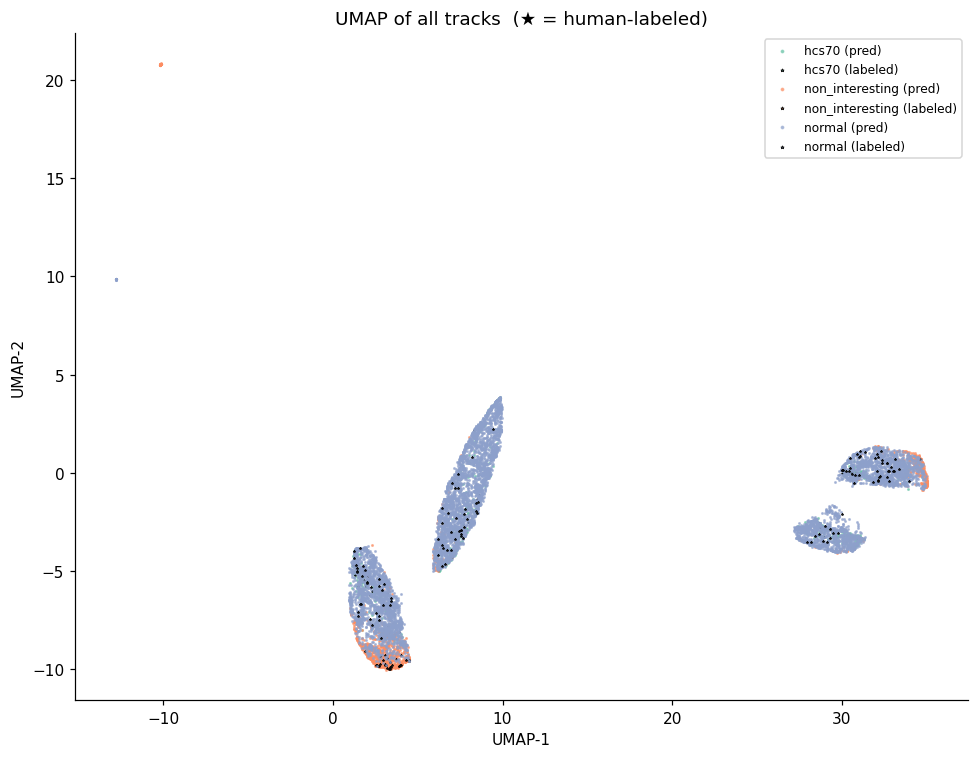

In [ ]:
fig, ax = plt.subplots(figsize=(9, 7))

is_labeled = labeler.get_labeled_mask()
pred_labels = df["predicted_label"].values

for label in label_order:
    mask_pred = pred_labels == label
    # predicted-only (unlabeled by human) — small dots
    m = mask_pred & ~is_labeled
    ax.scatter(
        emb[m, 0],
        emb[m, 1],
        s=1,
        alpha=0.6,
        color=color_map[label],
        label=f"{label} (pred)",
    )
    # human-labeled — large outlined stars
    m = mask_pred & is_labeled
    ax.scatter(
        emb[m, 0],
        emb[m, 1],
        s=2,
        alpha=0.9,
        marker="*",
        color=color_map[label],
        edgecolors="black",
        linewidths=0.5,
        label=f"{label} (labeled)",
    )

ax.set_xlabel("UMAP-1")
ax.set_ylabel("UMAP-2")
ax.set_title("UMAP of all tracks  (★ = human-labeled)")
ax.legend(markerscale=1.5, fontsize=8, loc="best")
plt.tight_layout()
plt.show()

## 9. Per-Label: Example Traces

Shows the 6 highest-confidence predicted traces for each label.

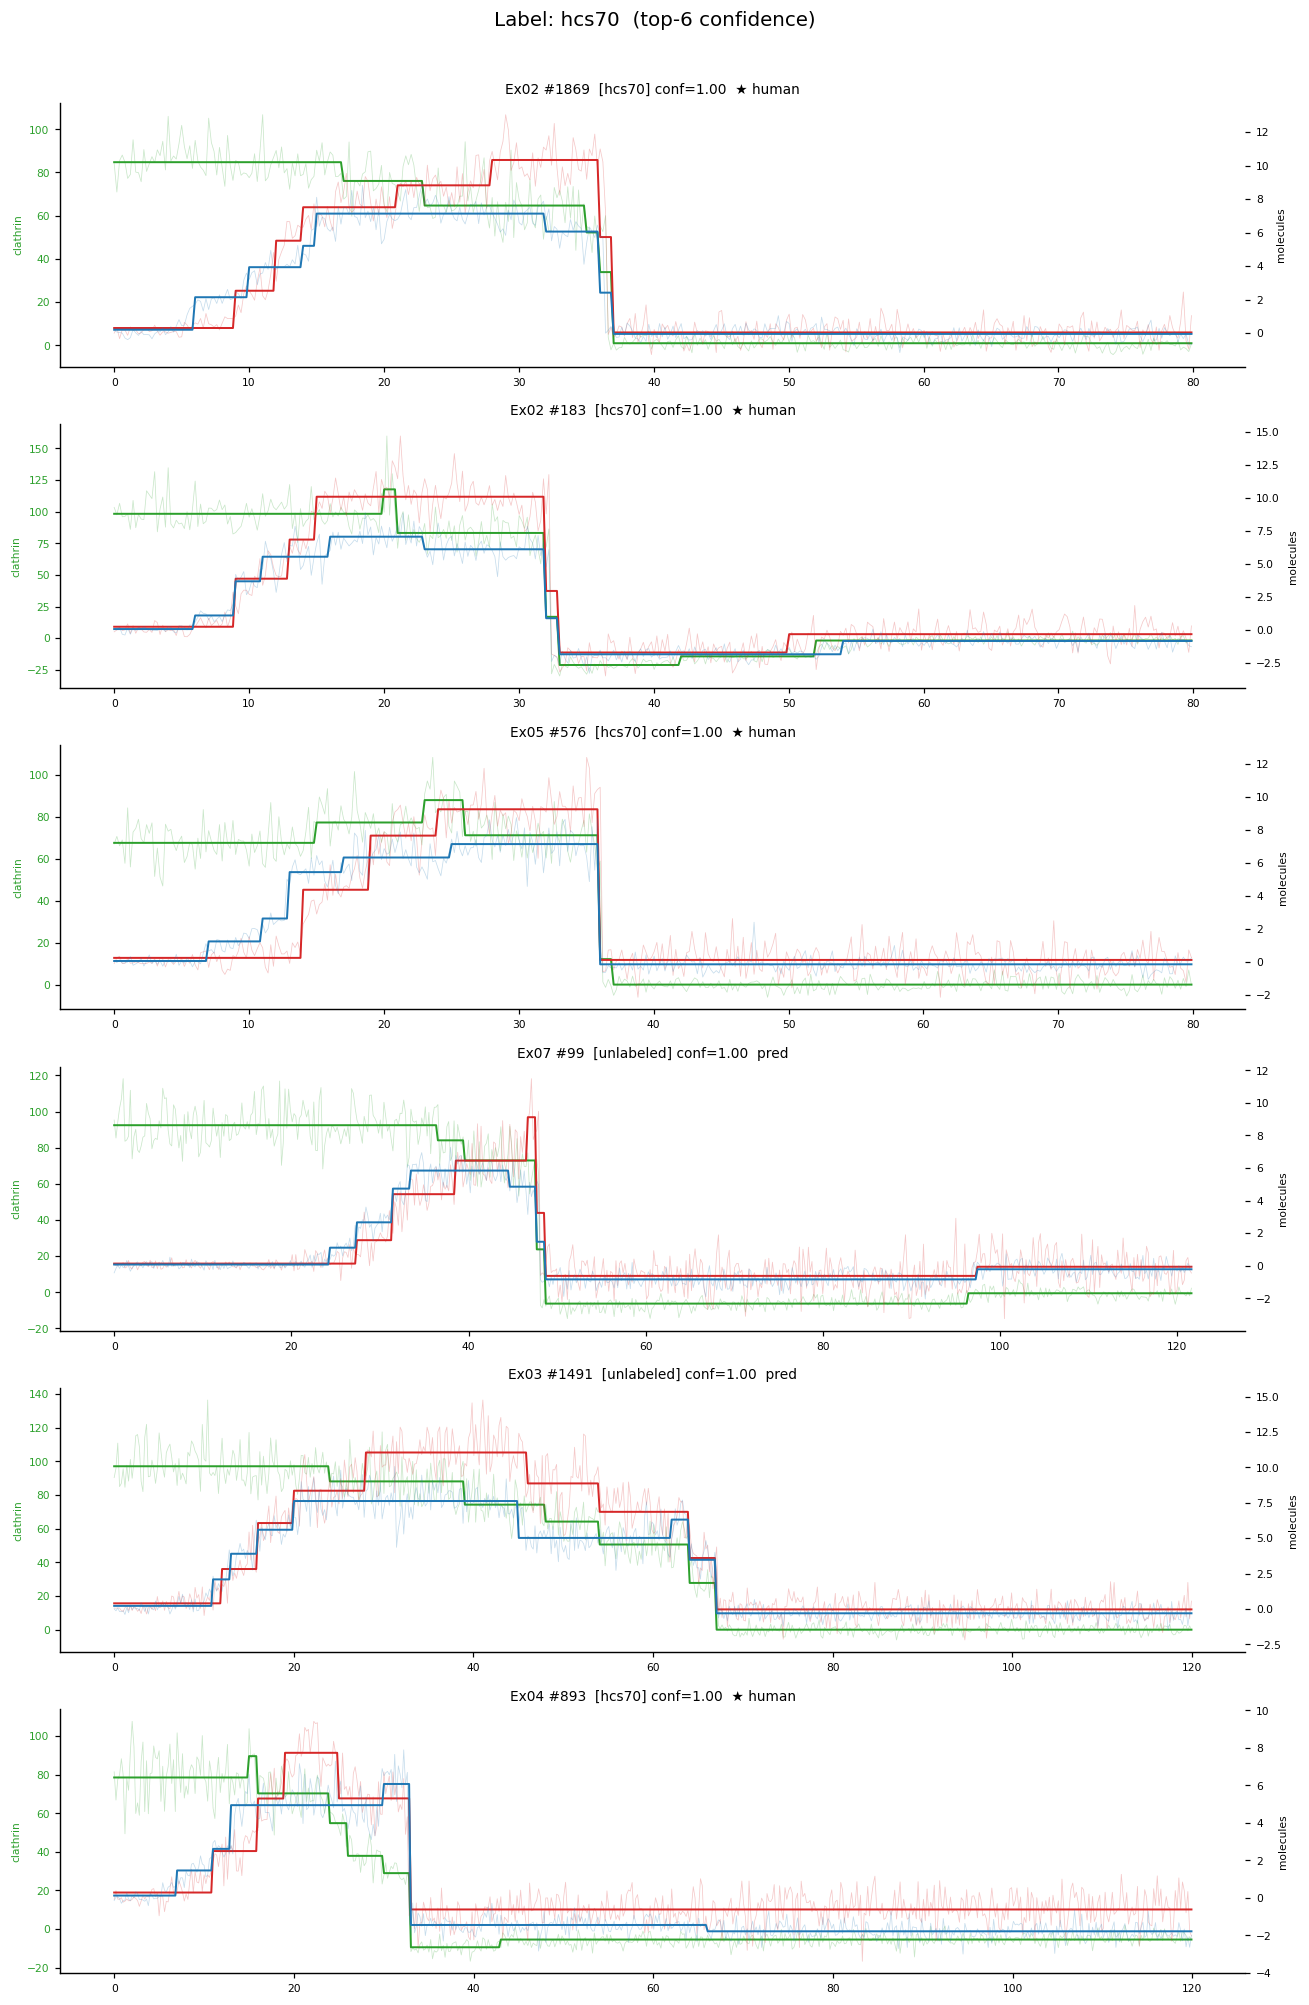

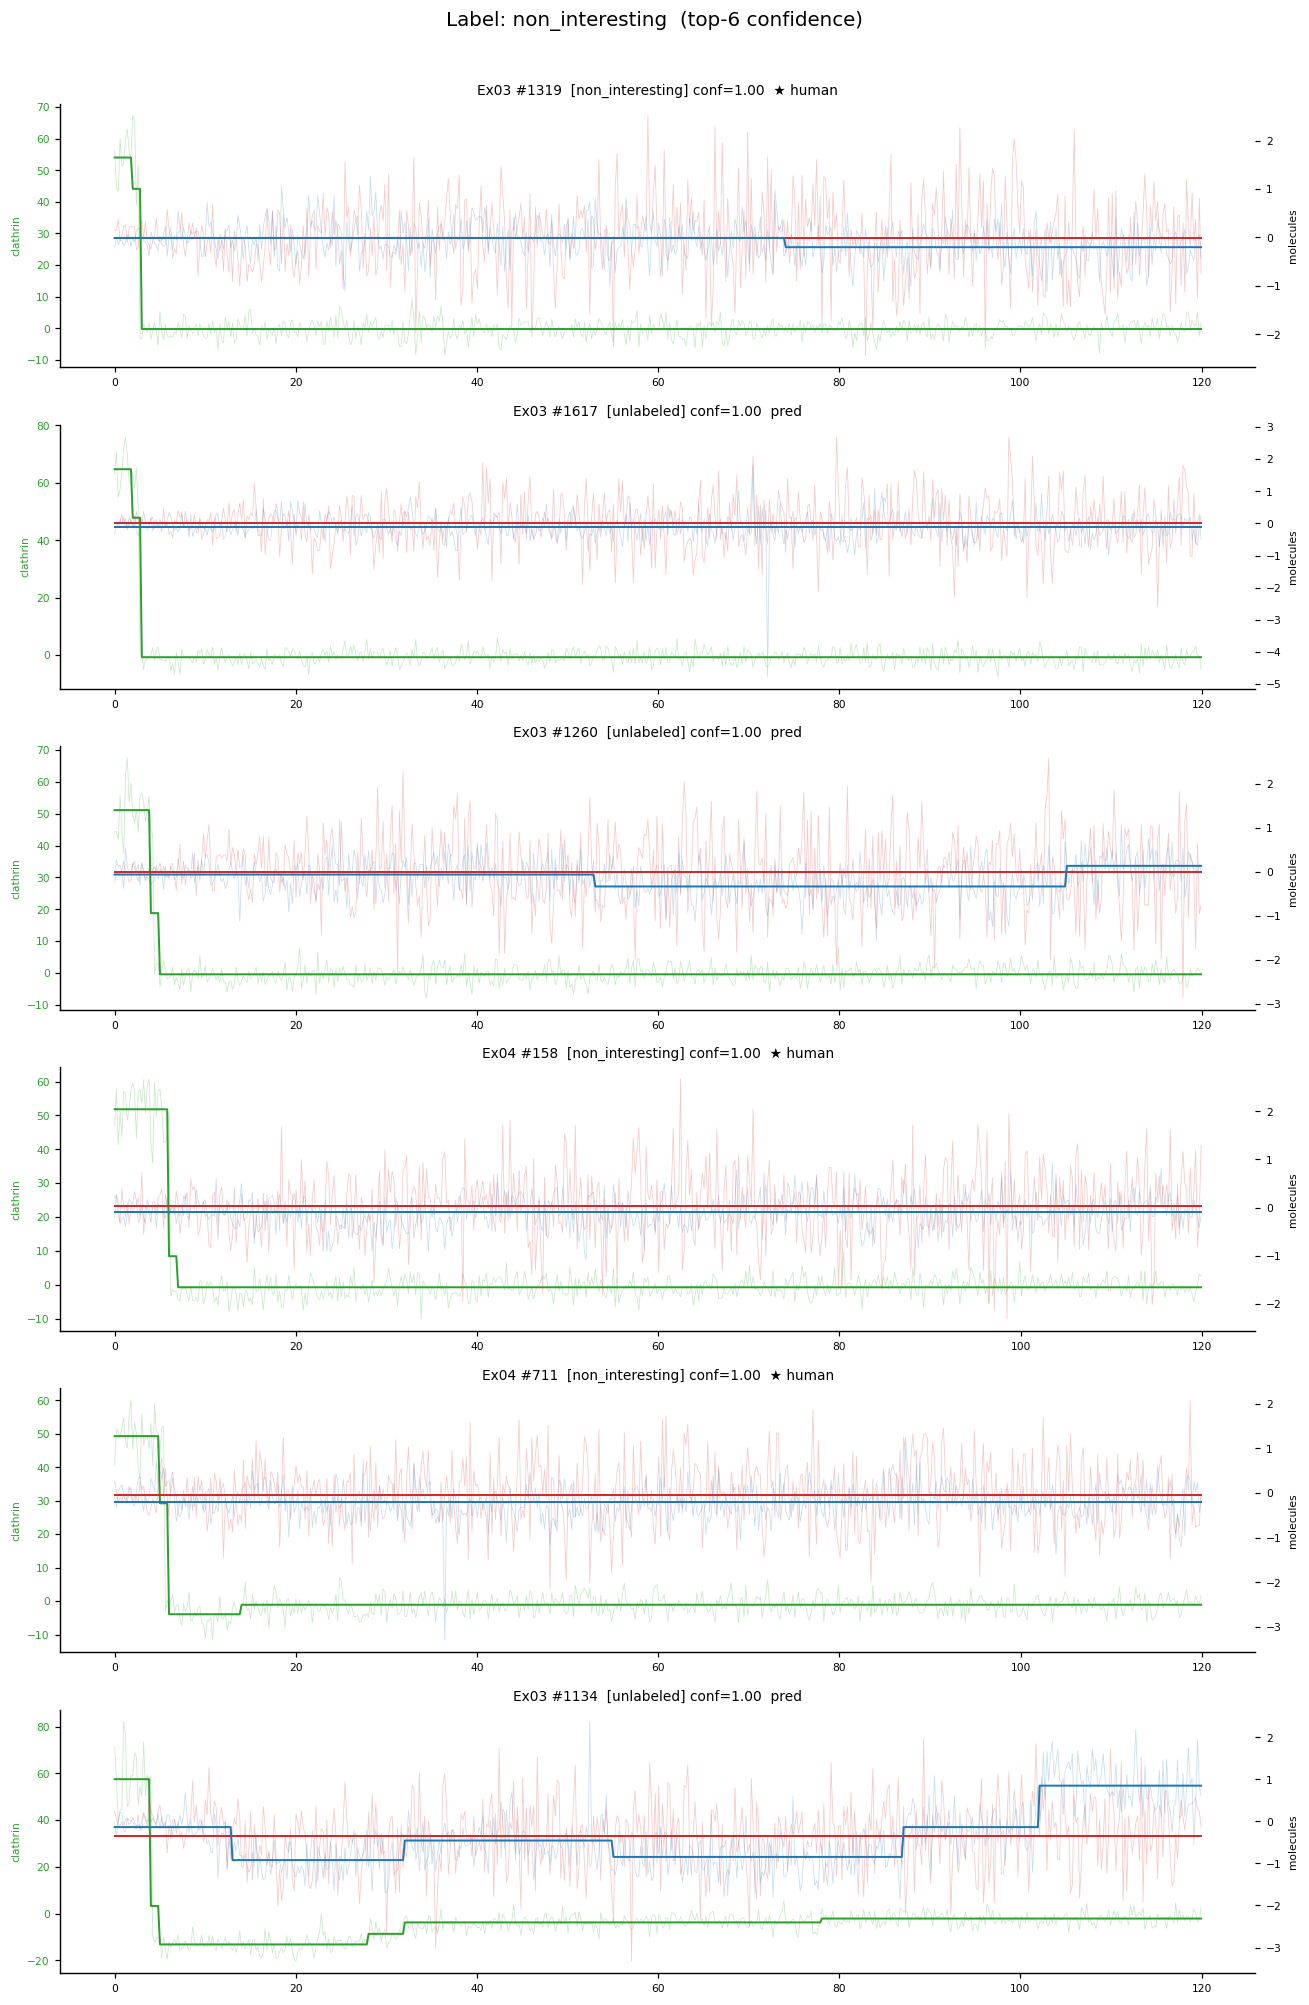

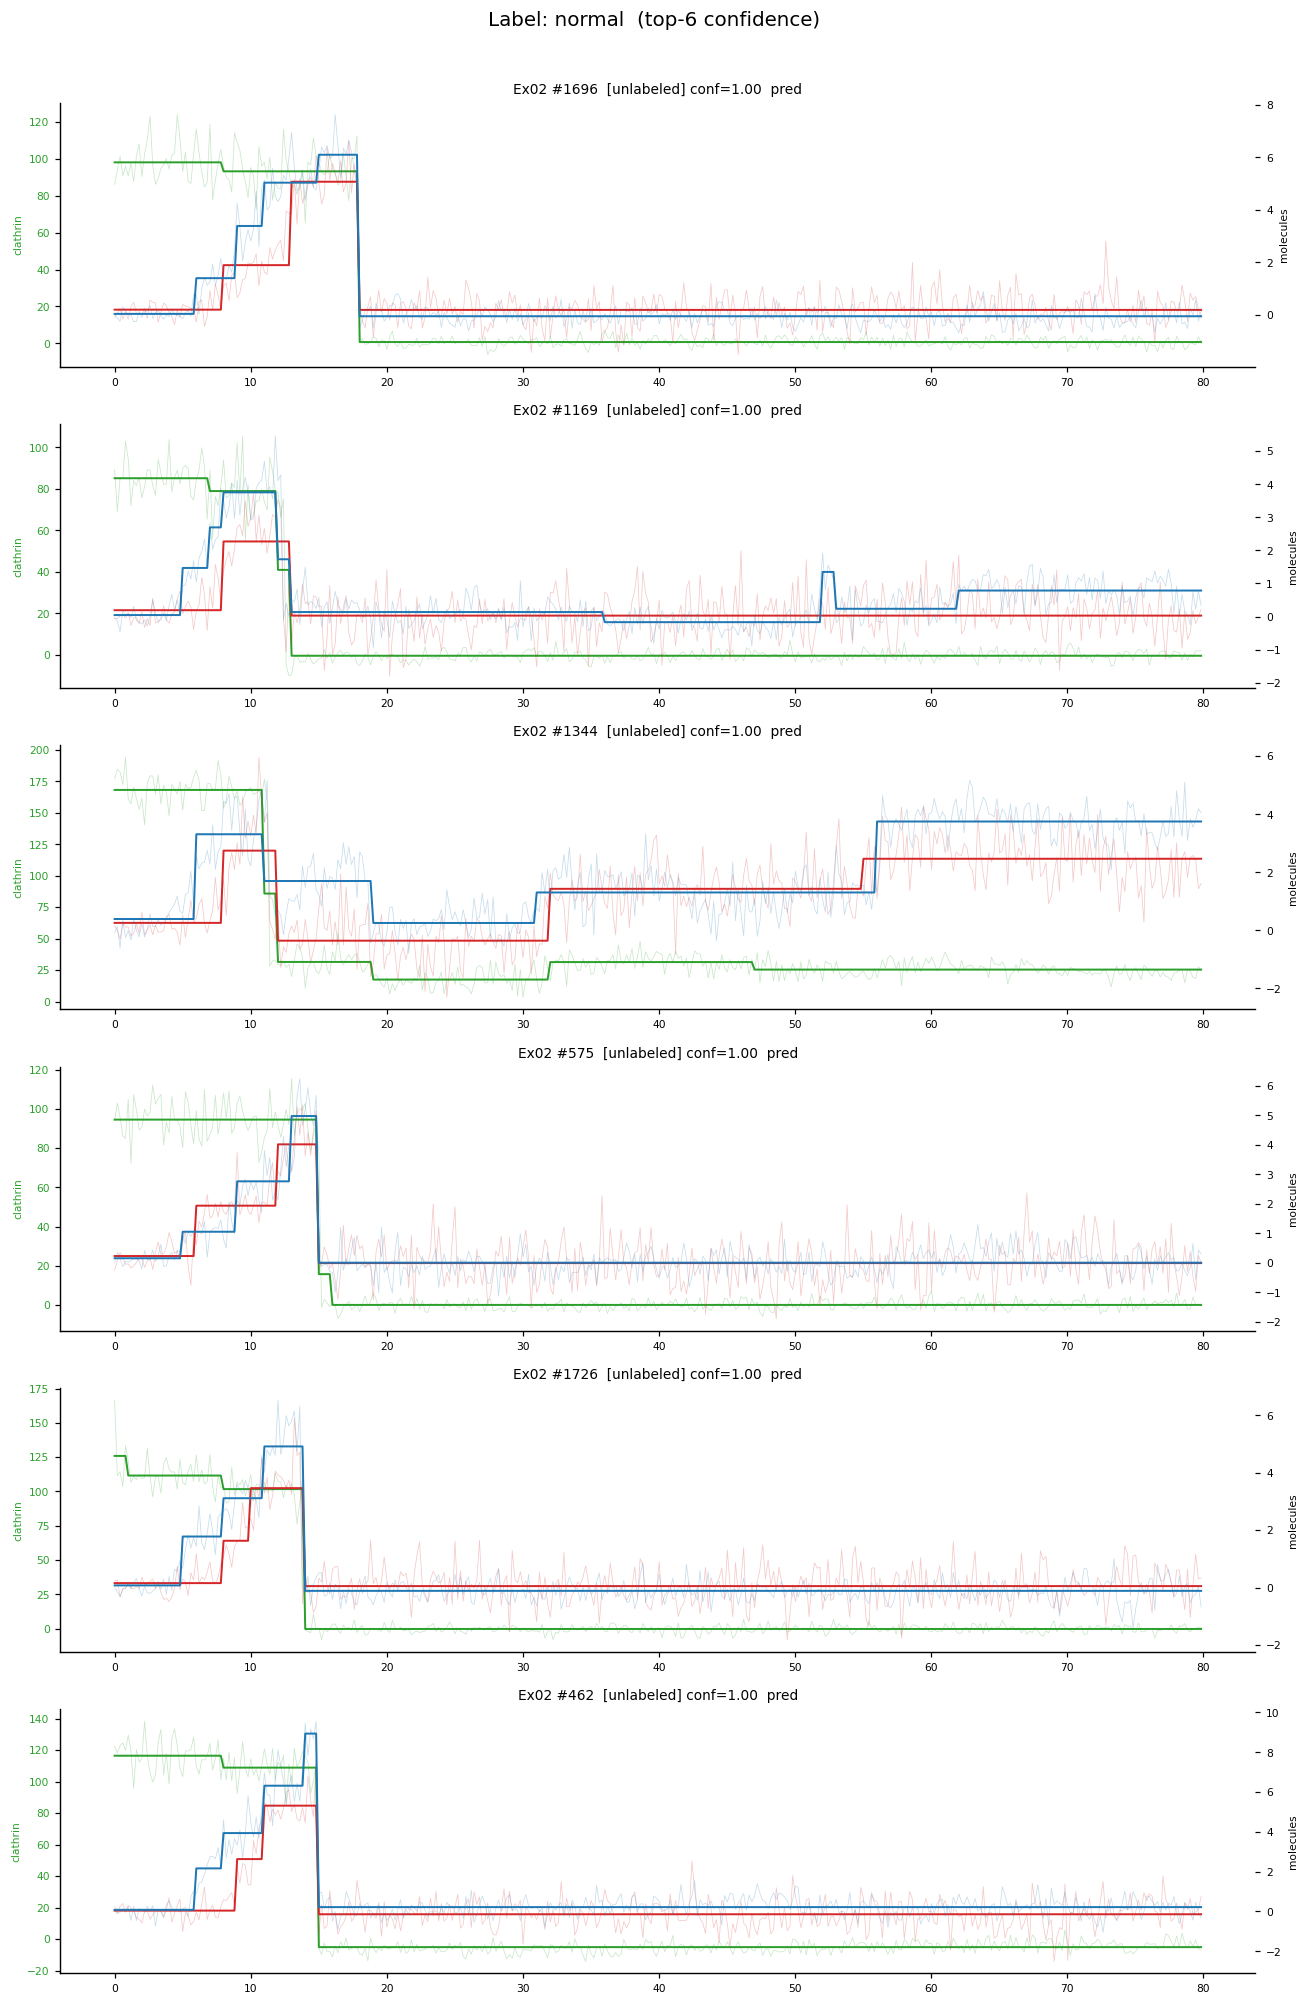

In [ ]:
N_EXAMPLES = 6  # change as desired

for label in label_order:
    subset = (
        df.loc[df.predicted_label == label]
        .sort_values("confidence", ascending=False)
        .head(N_EXAMPLES)
    )
    if subset.empty:
        continue

    n = len(subset)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=False)
    if n == 1:
        axes = [axes]
    fig.suptitle(f"Label: {label}  (top-{n} confidence)", fontsize=13, y=1.01)

    for ax, (_, row) in zip(axes, subset.iterrows()):
        labeler.plot_trace(
            row.exp,
            int(row.idx),
            ax=ax,
            title_extra=f"conf={row.confidence:.2f}  {'★ human' if row.is_labeled else 'pred'}",
        )

    plt.tight_layout()
    plt.show()

## 10. Per-Label: Key Statistics Summary

In [ ]:
SUMMARY_FEATURES = [
    "lifetime",
    "hsc70_mol_pos",
    "auxilin_mol_pos",
    "hsc70_n_pos_steps",
    "auxilin_n_pos_steps",
    "hsc70_aux_mol_ratio",
    "clathrin_net_change",
]
SUMMARY_FEATURES = [f for f in SUMMARY_FEATURES if f in df.columns]

summary = df.groupby("predicted_label")[SUMMARY_FEATURES].agg(
    ["median", "mean", "std", "count"]
)
pd.set_option("display.float_format", "{:.2f}".format)
summary

lifetime                    hsc70_mol_pos                    \
                  median   mean   std count        median  mean   std count   
predicted_label                                                               
hcs70             120.11 104.10 19.80   577         92.35 97.88 50.65   577   
non_interesting   120.11 109.25 18.09  1176          0.00  4.86 14.15  1176   
normal            120.11 106.75 19.11  7405         66.82 79.69 58.00  7405   

                auxilin_mol_pos         ... auxilin_n_pos_steps        \
                         median   mean  ...                 std count   
predicted_label                         ...                             
hcs70                     72.15 103.48  ...                1.27   577   
non_interesting           12.31  24.47  ...                1.35  1176   
normal                    91.47 125.47  ...                1.52  7405   

                hsc70_aux_mol_ratio                             \
                             median      mean        std count   
predicted_label                                                  
hcs70                          1.33 178760.89 2045159.26   577   
non_interesting                0.00  82711.28  954187.04  1176   
normal                         0.70      0.74       0.38  7405   

                clathrin_net_change                     
                             median   mean   std count  
predicted_label                                         
hcs70                        -54.26 -70.78 42.34   577  
non_interesting              -56.85 -57.75 30.80  1126  
normal                       -65.91 -74.58 45.12  7384  

[3 rows x 28 columns]

## 11. Agreement: Human Labels vs. Predictions

Confusion matrix on the human-labeled subset.

                 precision    recall  f1-score   support

          hcs70       1.00      1.00      1.00        66
non_interesting       1.00      1.00      1.00        33
         normal       1.00      1.00      1.00       118

       accuracy                           1.00       217
      macro avg       1.00      1.00      1.00       217
   weighted avg       1.00      1.00      1.00       217



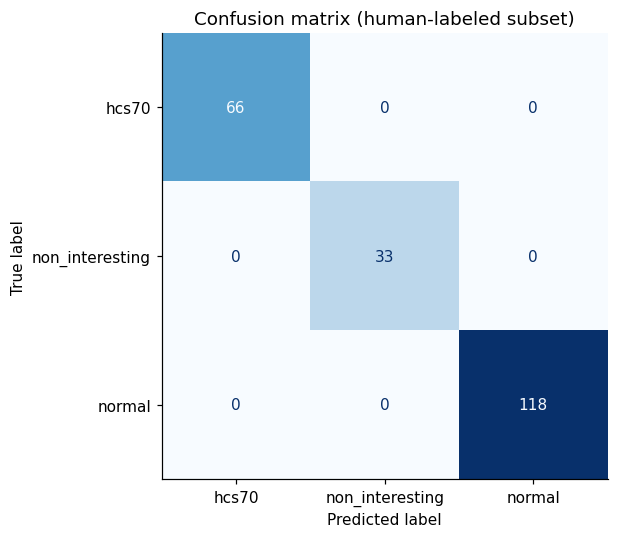

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report

labeled_df = df[df.is_labeled]
y_true = labeled_df["human_label"]
y_pred = labeled_df["predicted_label"]

print(classification_report(y_true, y_pred))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_true,
    y_pred,
    display_labels=label_order,
    cmap="Blues",
    ax=ax,
    colorbar=False,
)
ax.set_title("Confusion matrix (human-labeled subset)")
plt.tight_layout()
plt.show()

## 13. Per-Experiment Breakdown

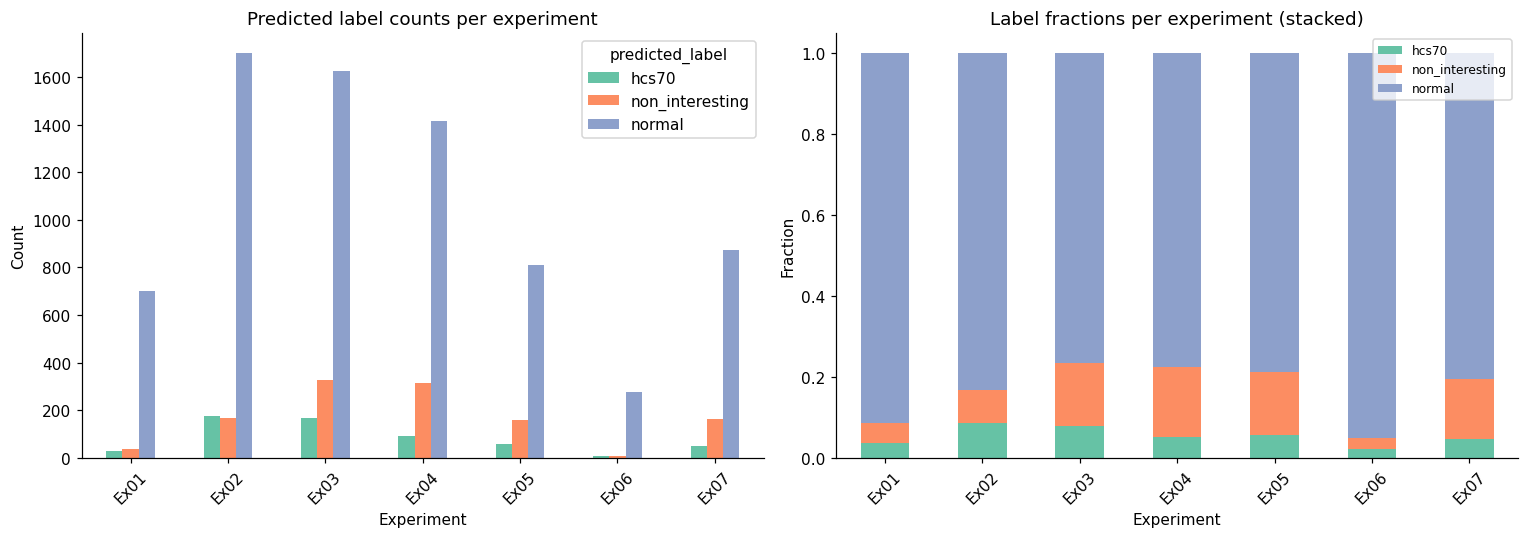

predicted_label,hcs70,non_interesting,normal
exp,,,
Ex01,27,38,700
Ex02,176,166,1700
Ex03,167,328,1628
Ex04,93,315,1417
Ex05,57,160,809
Ex06,6,8,276
Ex07,51,161,875


In [ ]:
exp_label = df.groupby(["exp", "predicted_label"]).size().unstack(fill_value=0)
exp_label_frac = exp_label.div(exp_label.sum(axis=1), axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

exp_label.plot(kind="bar", ax=axes[0], color=[color_map[c] for c in exp_label.columns])
axes[0].set_title("Predicted label counts per experiment")
axes[0].set_xlabel("Experiment")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

exp_label_frac.plot(
    kind="bar",
    stacked=True,
    ax=axes[1],
    color=[color_map[c] for c in exp_label_frac.columns],
)
axes[1].set_title("Label fractions per experiment (stacked)")
axes[1].set_xlabel("Experiment")
axes[1].set_ylabel("Fraction")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

exp_label

## 14. Low-Confidence Cases (worth reviewing in the GUI)

In [ ]:
CONFIDENCE_THRESHOLD = 0.6

uncertain = df.loc[~df.is_labeled & (df.confidence < CONFIDENCE_THRESHOLD)].sort_values(
    "confidence"
)[["exp", "idx", "predicted_label", "confidence"] + [f"prob_{c}" for c in classes]]
print(f"{len(uncertain)} unlabeled tracks with confidence < {CONFIDENCE_THRESHOLD}")
uncertain.head(20)

230 unlabeled tracks with confidence < 0.6


,exp,idx,predicted_label,confidence,prob_hcs70,prob_non_interesting,prob_normal
8167,Ex07,96,normal,0.40,0.22,0.38,0.40
2817,Ex03,10,hcs70,0.40,0.40,0.32,0.28
3108,Ex03,301,non_interesting,0.45,0.18,0.45,0.36
3435,Ex03,628,normal,0.46,0.32,0.22,0.46
3125,Ex03,318,non_interesting,0.48,0.26,0.48,0.26
5205,Ex04,275,normal,0.48,0.35,0.16,0.48
6520,Ex04,1590,normal,0.49,0.03,0.48,0.49
5413,Ex04,483,non_interesting,0.50,0.34,0.50,0.17
7134,Ex05,379,non_interesting,0.50,0.00,0.50,0.50
763,Ex01,763,normal,0.50,0.06,0.44,0.50
